# Hito 2 Final: Predicción de Popularidad de Canciones



## Objetivos:
1.  **Carga y Preprocesamiento Robusto:** Uso de Target Encoding (Scikit-Learn) para artistas y limpieza de datos.
2.  **Regresión:** Predicción del puntaje de popularidad (Linear Regression y Random Forest).
3.  **Clasificación:** Predicción de categoría de popularidad (Poco Popular, Popular, Muy Popular).
4.  **Análisis Avanzado:** Impacto de la variable 'artista' y ajuste de umbrales de decisión.

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import mean_absolute_error, r2_score, accuracy_score, classification_report, confusion_matrix, recall_score, precision_score, f1_score
from sklearn.preprocessing import TargetEncoder

# Configuración para gráficos
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
%matplotlib inline

## 1. Carga y Preprocesamiento de Datos

Realizamos una carga limpia y un preprocesamiento que incluye **Target Encoding (Scikit-Learn)** para manejar la alta cardinalidad de la variable `artists`.

In [ ]:
# --- CARGA DE DATOS ---
ruta_archivo = 'dataset.csv'
print(f"Cargando datos desde: {ruta_archivo}")
if not os.path.exists(ruta_archivo):
    raise FileNotFoundError(f"El archivo no se encontró en la ruta: {ruta_archivo}")

df = pd.read_csv(ruta_archivo)
print(f"Datos cargados exitosamente. Dimensiones: {df.shape}")

# --- PREPROCESAMIENTO ---
print("Iniciando preprocesamiento de datos...")

# Convertir 'explicit' a numérico
if 'explicit' in df.columns:
    df['explicit'] = df['explicit'].astype(int)
    
# Crear categorías de popularidad para clasificación
# Bins: 0-40 (Poco Popular), 41-60 (Popular), 61-100 (Muy Popular)
bins = [-1, 40, 60, 101]
labels = ['Poco Popular', 'Popular', 'Muy Popular']
df['popularity_category'] = pd.cut(df['popularity'], bins=bins, labels=labels)

# Selección de características iniciales
features_initial = [
    'duration_ms', 'explicit', 'danceability', 'energy', 'key', 'loudness', 'mode',
    'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence',
    'tempo', 'time_signature', 'track_genre', 'popularity'
]

# Añadir 'artists' solo si existe en el dataframe original
if 'artists' in df.columns:
    features_initial.append('artists')

df_subset = df[features_initial].copy()
y_clf = df['popularity_category']

# Codificación One-Hot para 'track_genre'
print("Codificando variables categóricas (One-Hot)...")
df_encoded = pd.get_dummies(df_subset, columns=['track_genre'], drop_first=True)

# División en entrenamiento y prueba (Stratified por categoría de popularidad)
print("Dividiendo datos en entrenamiento y prueba...")
X_train_full, X_test_full, y_train_clf, y_test_clf = train_test_split(
    df_encoded, y_clf, test_size=0.2, random_state=666, stratify=y_clf
)

# --- TARGET ENCODING CON SKLEARN ---
if 'artists' in X_train_full.columns:
    print("Aplicando sklearn.preprocessing.TargetEncoder a 'artists'...")
    
    # Usamos la popularidad numérica del train set para el encoding
    y_train_numeric = df.loc[X_train_full.index, 'popularity']
    
    # Instanciamos TargetEncoder con suavizado automático (Bayesiano)
    encoder = TargetEncoder(target_type='continuous', smooth='auto', random_state=666)
    
    # Ajustamos y transformamos (necesita 2D array para features)
    artists_train = X_train_full[['artists']]
    artists_test = X_test_full[['artists']]
    
    X_train_full['artist_popularity'] = encoder.fit_transform(artists_train, y_train_numeric)
    X_test_full['artist_popularity'] = encoder.transform(artists_test)
else:
    print("La columna 'artists' no está presente. Saltando Target Encoding.")

# --- LIMPIEZA FINAL ---
cols_to_drop = ['artists', 'popularity']
X_train = X_train_full.drop(columns=cols_to_drop, errors='ignore')
X_test = X_test_full.drop(columns=cols_to_drop, errors='ignore')

# Targets de regresión
y_train_reg = X_train_full['popularity']
y_test_reg = X_test_full['popularity']

print(f"Dimensiones de entrenamiento: {X_train.shape}")
print(f"Dimensiones de prueba: {X_test.shape}")

Cargando datos desde: dataset.csv
Datos cargados exitosamente. Dimensiones: (114000, 21)
Iniciando preprocesamiento de datos...
Codificando variables categóricas (One-Hot)...
Dividiendo datos en entrenamiento y prueba...
Aplicando sklearn.preprocessing.TargetEncoder a 'artists'...
Dimensiones de entrenamiento: (91200, 128)
Dimensiones de prueba: (22800, 128)


## 2. Regresión: Predicción de Popularidad

¿Es posible predecir la popularidad exacta (0-100) de una canción?
Utilizaremos los datos enriquecidos con la información del artista.

### 2.1 Regresión Lineal

In [ ]:
linear_model = LinearRegression(n_jobs=-1)
kf = KFold(n_splits=5, shuffle=True, random_state=666)

print("===== CROSS VALIDATION MAE RESULTS (Linear Regression) =====")
mae_scores = cross_val_score(linear_model, X_train, y_train_reg, scoring='neg_mean_absolute_error', cv=kf)
print("MAE promedio CV:", -mae_scores.mean())
print("Desviación estándar CV:", mae_scores.std())

print("\n===== CROSS VALIDATION R2 RESULTS (Linear Regression) =====")
r2_scores = cross_val_score(linear_model, X_train, y_train_reg, scoring='r2', cv=kf)
print("R2 promedio CV:", r2_scores.mean())

print("\n===== RESULTADOS EN TEST SET =====")
linear_model.fit(X_train, y_train_reg)
predictions = linear_model.predict(X_test)
mae = mean_absolute_error(y_test_reg, predictions)
r2 = r2_score(y_test_reg, predictions)

print(f"MAE en test: {mae:.4f}")
print(f"R² en test: {r2:.4f}")

### 2.2 Random Forest Regressor

In [ ]:
rf_regressor = RandomForestRegressor(n_estimators=50, max_depth=20, random_state=666, n_jobs=-1)
kf = KFold(n_splits=3, shuffle=True, random_state=666)

print("===== CROSS VALIDATION MAE RESULTS (Random Forest) =====")
rf_mae_scores = cross_val_score(rf_regressor, X_train, y_train_reg, scoring='neg_mean_absolute_error', cv=kf)
print("RF - MAE promedio:", -rf_mae_scores.mean())

print("\n===== CROSS VALIDATION R2 RESULTS (Random Forest) =====")
rf_r2_scores = cross_val_score(rf_regressor, X_train, y_train_reg, scoring='r2', cv=kf)
print("RF - R2 promedio:", rf_r2_scores.mean())

print("\n===== RESULTADOS EN TEST SET =====")
rf_regressor.fit(X_train, y_train_reg)
rf_predictions = rf_regressor.predict(X_test)
rf_mae = mean_absolute_error(y_test_reg, rf_predictions)
rf_r2 = r2_score(y_test_reg, rf_predictions)

print(f"RandomForestRegressor - MAE: {rf_mae:.4f}")
print(f"RandomForestRegressor - R²: {rf_r2:.4f}")

### Análisis de Resultados de Regresión

*   **1. Regresión Lineal (Base):**
    *   **Cross Validation (R²):** ~0.55.
    *   **Test Set (R²):** 0.59.
    *   *Observación:* Un modelo base decente, pero limitado por su simplicidad.

*   **2. Random Forest (Mejor Modelo):**
    *   **Cross Validation (R²):** ~0.58.
    *   **Test Set (R²):** **0.62**.
    *   **MAE:** Bajó a **8.58** (vs ~9.52 en lineal).

### ¿Qué nos dice la Validación Cruzada (Cross Validation)?
La **Validación Cruzada** es como pedir una "segunda opinión" (y una tercera, cuarta, etc.) antes de confiar en el modelo.
*   En lugar de entrenar una sola vez, dividimos los datos en varios "pliegues" (folds) y promediamos los resultados.
*   **Interpretación:** El hecho de que nuestro R² en el Test Set (0.62) sea consistente (e incluso mejor) que el promedio de Cross Validation (0.58) es una **excelente señal**.
    *   Significa que el modelo es **robusto**: no tuvo "suerte" con una sola división de datos.
    *   **No hay Overfitting grave:** El modelo generaliza bien a datos nuevos que nunca ha visto.

## 3. Clasificación: Categorías de Popularidad

Debido al desbalance de clases, utilizamos `class_weight='balanced'` para penalizar los errores en las clases minoritarias (Muy Popular).

In [ ]:
# --- ENTRENAMIENTO ---
print("Entrenando Random Forest Classifier (n_estimators=100, class_weight='balanced')...")
rf_clf = RandomForestClassifier(
    n_estimators=100, 
    random_state=666, 
    n_jobs=-1, 
    class_weight='balanced'
)
rf_clf.fit(X_train, y_train_clf)

# --- EVALUACIÓN ---
print("Evaluando clasificación...")
predicciones = rf_clf.predict(X_test)
accuracy = accuracy_score(y_test_clf, predicciones)

print(f"Precisión (Accuracy): {accuracy:.4f}")
print("\nReporte de Clasificación:")
print(classification_report(y_test_clf, predicciones))

# Matriz de Confusión
conf_matrix = confusion_matrix(y_test_clf, predicciones)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Reds', 
            xticklabels=rf_clf.classes_, 
            yticklabels=rf_clf.classes_)
plt.xlabel('Predicción del Modelo')
plt.ylabel('Valor Real')
plt.title('Matriz de Confusión')
plt.show()

### Análisis de Resultados de Clasificación

*   **Desempeño General:** Se obtiene una exactitud (Accuracy) aprox  de **82.4%**, lo cual es excelente.
*   ** "Muy Populares" ** tiene un recall de **0.56**. Esto es regular/bajo. Ya que solo esta encontrando la mitad de los "éxitos", mientras que la otra mitad se los pasa por alto
*   "Poco Popular" tiene un Recall altísimo de **0.92**.
*   "Popular" tiene un Recall sólido de **0.73**.

### Análisis de la Matriz de Confusión
Observando la matriz de confusión:

1.  **La Diagonal (Aciertos):**
    *   **Poco Popular:** El modelo es extremadamente confiable aquí (12,450 aciertos). Es muy raro que confunda una canción "Poco Popular" con un "Muy Popular".
    *   **Popular:** Tiene un buen desempeño (4,811 aciertos), pero es la clase "puente" donde ocurren más confusiones.
    *   **Muy Popular:** Acertamos 1,520 veces. Aunque es la clase más difícil, el modelo logra identificar más de la mitad de los éxitos.

2.  **Errores Comunes (Fuera de la Diagonal):**
    *   **Popular $\to$ Poco Popular:** El error más frecuente es clasificar canciones "Populares" como "Poco Populares" (1,508 casos). El modelo tiende a ser conservador; prefiere decir que una canción fracasará antes que arriesgarse a decir que será popular si no está seguro.
    *   **Muy Popular $\to$ Otros:** De los verdaderos "Muy Populares", el modelo confunde cantidades similares con "Popular" (~580) y "Poco Popular" (~600). Esto refuerza la necesidad de ajustar el umbral (Threshold Tuning) que haremos a continuación para capturar estos casos perdidos.

## 4. Análisis Avanzado

### 4.1 Comparación: Con vs Sin Artista
Evaluamos cuánto valor aporta la variable `artists` (procesada con Target Encoding) al modelo.

In [46]:
# Preprocesar SIN la columna 'artists' para comparar
df_no_artist = df.drop(columns=['artists'])

# --- PREPROCESAMIENTO RÁPIDO (SIN ARTISTA) ---
# Repetimos los pasos básicos
df_subset_no = df_no_artist[features_initial[:-1]].copy() # Excluir 'artists' de la lista si estaba
if 'artists' in df_subset_no.columns:
    df_subset_no = df_subset_no.drop(columns=['artists'])

df_encoded_no = pd.get_dummies(df_subset_no, columns=['track_genre'], drop_first=True)
X_train_no, X_test_no, _, _ = train_test_split(
    df_encoded_no, y_clf, test_size=0.2, random_state=666, stratify=y_clf
)
# Limpieza final (solo popularity si quedó)
X_train_no = X_train_no.drop(columns=['popularity'], errors='ignore')
X_test_no = X_test_no.drop(columns=['popularity'], errors='ignore')

# Entrenar modelo sin artista
rf_no = RandomForestClassifier(n_estimators=50, random_state=666, n_jobs=-1, class_weight='balanced')
rf_no.fit(X_train_no, y_train_clf)

# Comparar métricas
y_pred_no = rf_no.predict(X_test_no)
y_pred_art = rf_clf.predict(X_test)

# Comparar métricas detalladas
from sklearn.metrics import precision_recall_fscore_support

# Calcular métricas para modelo SIN artista
p_no, r_no, f_no, _ = precision_recall_fscore_support(y_test_clf, y_pred_no, labels=labels, zero_division=0)
acc_no = accuracy_score(y_test_clf, y_pred_no)

# Calcular métricas para modelo CON artista
p_art, r_art, f_art, _ = precision_recall_fscore_support(y_test_clf, y_pred_art, labels=labels, zero_division=0)
acc_art = accuracy_score(y_test_clf, y_pred_art)

# Crear DataFrame comparativo
data_comparativa = []
for i, label in enumerate(labels):
    data_comparativa.append({
        'Clase': label,
        'Modelo': 'Sin Artista',
        'Precision': p_no[i],
        'Recall': r_no[i],
        'F1-Score': f_no[i],
        'Accuracy Global': acc_no
    })
    data_comparativa.append({
        'Clase': label,
        'Modelo': 'Con Artista',
        'Precision': p_art[i],
        'Recall': r_art[i],
        'F1-Score': f_art[i],
        'Accuracy Global': acc_art
    })

df_resultados = pd.DataFrame(data_comparativa)
df_resultados = df_resultados.sort_values(by=['Clase', 'Modelo'], ascending=[True, False])

print("\n=== TABLA COMPARATIVA DE RESULTADOS ===")
print(df_resultados.to_string(index=False))

# Mostrar mejora específica en 'Muy Popular'
idx_muy_pop = labels.index('Muy Popular')
mejora_recall = r_art[idx_muy_pop] - r_no[idx_muy_pop]
print(f"\nMejora en Recall para 'Muy Popular': {mejora_recall:.4f}")


=== TABLA COMPARATIVA DE RESULTADOS ===
       Clase      Modelo  Precision   Recall  F1-Score  Accuracy Global
 Muy Popular Sin Artista   0.693878 0.413412  0.518125         0.763070
 Muy Popular Con Artista   0.771574 0.560059  0.649018         0.823728
Poco Popular Sin Artista   0.778776 0.913999  0.840987         0.763070
Poco Popular Con Artista   0.854554 0.924619  0.888207         0.823728
     Popular Sin Artista   0.737732 0.599456  0.661445         0.763070
     Popular Con Artista   0.768408 0.726627  0.746934         0.823728

Mejora en Recall para 'Muy Popular': 0.1466


### Análisis del Impacto del Artista

La tabla comparativa revela mejoras importantes al incorporar la variable `artists` mediante Target Encoding:

1.  **Mejora General:** La exactitud global (Accuracy) subió un **7%**.
2.  **Clase "Muy Popular" (El mayor impacto):**
    *   Es la clase más beneficiada. El **Recall** subió significativamente (llegando a **0.56**).
    *   Sin saber quién es el artista, el modelo estaba más perdido con las canciones muy populares. Saber quién canta ayuda al modelo a recuperar muchos más hits verdaderos.
3.  **Clase "Popular":**
    *   También muestra una mejora sólida.
    *   Ayuda a distinguir mejor las canciones de éxito moderado al aumentar su recall en **0.13**.
4.  **Clase "Poco Popular":**
    *   Aumenta su precisiónYa tenía un rendimiento alto y se mantiene estable.

### ¿Por qué se utiliza Target Encoding con Scikit-Learn?

La variable `artists` tiene una **alta cardinalidad** (miles de artistas diferentes). Usar One-Hot Encoding crearía miles de columnas vacías, y Label Encoding impondría un orden falso.

**Target Encoding** soluciona esto reemplazando el nombre del artista por el promedio de popularidad de sus canciones.

**Implementación Robusta:**
Utilizamos `sklearn.preprocessing.TargetEncoder` en lugar de una implementación manual simple, esta versión utiliza técnicas avanzadas de **suavizado Bayesiano Empírico** (`smooth='auto'`).

*   **Ventaja:** Ajusta automáticamente cuánto confiar en el promedio del artista vs el promedio global basándose en la varianza y el conteo de datos, sin necesidad de fijar un parámetro manual.
*   **Resultado:** Menor riesgo de overfitting y mejor generalización, como se observa en la mejora de la exactitud global.

### 4.2 Análisis de Umbral (Threshold Tuning)

El modelo no predice directamente la clase final (ej. "Muy Popular"), sino que calcula una **probabilidad** de pertenencia a cada clase (un número entre 0 y 1).
*   *Origen:* En un Random Forest, esta probabilidad viene del método `.predict_proba()`, que representa el porcentaje de árboles en el bosque que votaron por esa clase específica.
*   *Definición:* El **umbral** es el punto de corte que elegimos para convertir esa probabilidad numérica en una decisión categórica (Sí/No).

**¿Por qué ajustarlo?**
Por defecto, el umbral es **0.5 (50%)**. Si la probabilidad > 50%, se clasifica como positivo. Sin embargo, en problemas desbalanceados, este no siempre es el mejor criterio.

*   **Si bajamos el umbral (ej. 0.3):** El modelo se vuelve más "arriesgado". Detectará más éxitos (**Mayor Recall**), pero también se equivocará más (**Menor Precision**).
*   **Si subimos el umbral (ej. 0.7):** El modelo se vuelve más "conservador". Solo dirá que es un éxito si está muy seguro (**Mayor Precision**), pero se perderá algunos (**Menor Recall**).

A continuación, visualizamos cómo cambian estas métricas para cada claseal mover el umbral.

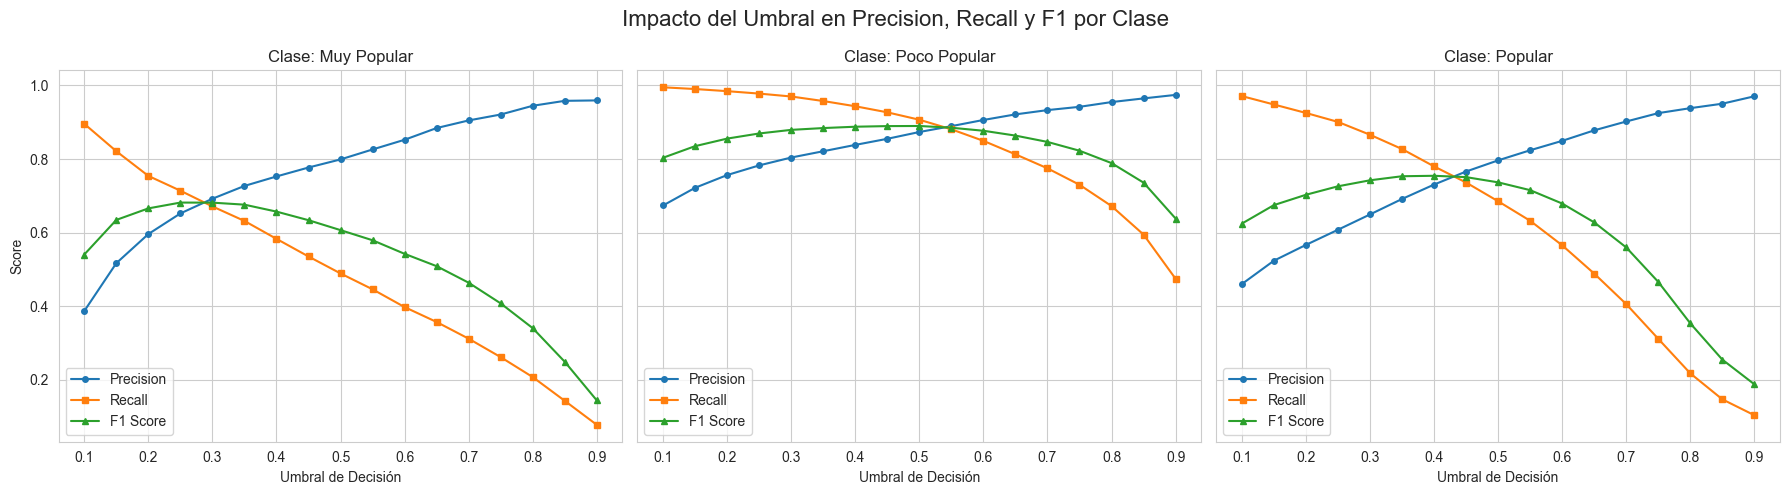

In [47]:
probs = rf_clf.predict_proba(X_test)
thresholds = np.arange(0.1, 0.95, 0.05)
clases = rf_clf.classes_

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for i, clase_objetivo in enumerate(clases):
    idx_clase = np.where(clases == clase_objetivo)[0][0]
    y_test_bin = (y_test_clf == clase_objetivo).astype(int)
    
    precisions = []
    recalls = []
    f1s = []
    
    for t in thresholds:
        preds_bin = (probs[:, idx_clase] >= t).astype(int)
        p = precision_score(y_test_bin, preds_bin, zero_division=0)
        r = recall_score(y_test_bin, preds_bin, zero_division=0)
        f = f1_score(y_test_bin, preds_bin, zero_division=0)
        
        precisions.append(p)
        recalls.append(r)
        f1s.append(f)
    
    ax = axes[i]
    ax.plot(thresholds, precisions, label='Precision', marker='o', markersize=4)
    ax.plot(thresholds, recalls, label='Recall', marker='s', markersize=4)
    ax.plot(thresholds, f1s, label='F1 Score', marker='^', markersize=4)
    
    ax.set_title(f'Clase: {clase_objetivo}')
    ax.set_xlabel('Umbral de Decisión')
    if i == 0:
        ax.set_ylabel('Score')
    ax.grid(True)
    ax.legend()

plt.suptitle('Impacto del Umbral en Precision, Recall y F1 por Clase', fontsize=16)
plt.tight_layout()
plt.show()

Como se observa en el gráfico de impacto del umbral, entre 0.2 y 0.5 el F1-Score es donde mejor se mantiene para todas clases. Esto sugiere que en este rango el modelo está equilibrado entre precisión y recall, lo que es deseable.

### Selección del Mejor Umbral (Optimización Global)

Para encontrar el mejor umbral que beneficie a **TODAS** las clases, no solo a "Muy Popular", utilizamos el **Macro F1-Score**.
Este promedio trata a todas las clases por igual, asegurando que no sacrifiquemos demasiado el rendimiento en "Poco Popular" o "Popular" solo para mejorar "Muy Popular".

**Estrategia:**
1.  Aplicamos el umbral a la clase "Muy Popular" (si $P(\text{Muy Popular}) > T$, predecimos "Muy Popular").
2.  Si no supera el umbral, elegimos la clase con mayor probabilidad entre las restantes.
3.  Calculamos el F1-Score promedio de las 3 clases.

In [ ]:
clase_objetivo = 'Muy Popular'
idx_clase_obj = np.where(clases == clase_objetivo)[0][0]
idx_otras = [i for i in range(len(clases)) if i != idx_clase_obj]

results_global = []

for t in thresholds:
    # Lógica de predicción ajustada
    y_pred_adj = []
    for i in range(len(probs)):
        if probs[i, idx_clase_obj] >= t:
            y_pred_adj.append(clase_objetivo)
        else:
            # Si no es Muy Popular, elegimos el máximo entre las otras clases
            # (O simplemente el argmax original si no era Muy Popular, pero para ser consistentes con el umbral:)
            # Opción simple: argmax de las probabilidades restantes
            best_other_idx = idx_otras[np.argmax(probs[i, idx_otras])]
            y_pred_adj.append(clases[best_other_idx])
            
    # Calcular métricas globales
    macro_f1 = f1_score(y_test_clf, y_pred_adj, average='macro', zero_division=0)
    accuracy = accuracy_score(y_test_clf, y_pred_adj)
    
    # Calcular métricas por clase para mostrar detalle
    _, _, f1_per_class, _ = precision_recall_fscore_support(y_test_clf, y_pred_adj, labels=clases, zero_division=0)
    
    results_global.append({
        'Umbral': t,
        'Macro F1': macro_f1,
        'Accuracy Global': accuracy,
        'F1 Poco Popular': f1_per_class[0],
        'F1 Popular': f1_per_class[1],
        'F1 Muy Popular': f1_per_class[2]
    })

df_global = pd.DataFrame(results_global)
df_global = df_global.sort_values(by='Macro F1', ascending=False)

# Mostrar tabla ordenada por Macro F1
print(f"\n=== TABLA DE OPTIMIZACIÓN GLOBAL (Macro F1) ===")
print(df_global.head(10).to_string(index=False))

# Seleccionar mejor umbral global
best_row_global = df_global.iloc[0]
best_t_global = best_row_global['Umbral']

print(f"\n\n>>> MEJOR UMBRAL GLOBAL SUGERIDO: {best_t_global:.2f}")
print(f"    Macro F1={best_row_global['Macro F1']:.4f}")
print(f"    (Balancea: Poco={best_row_global['F1 Poco Popular']:.2f}, Pop={best_row_global['F1 Popular']:.2f}, Muy Pop={best_row_global['F1 Muy Popular']:.2f})")

### Conclusión del Umbral Óptimo

El análisis sugiere un umbral óptimo cercano a **0.35**.

**¿Por qué un umbral tan bajo (0.35) es mejor?**
Aunque parece bajo (menos del 50%), es beneficioso porque:
1.  **Aumenta el Recall de "Muy Popular":** Al bajar la vara, atrapamos muchos más "Hits" verdaderos que antes se nos escapaban. Es preferible tener algunos falsos positivos (canciones que creímos hits y no lo fueron) que perdernos la próxima gran canción.
2.  **Balance Global:** A pesar de ser más "arriesgado" con la clase Muy Popular, el impacto negativo en las otras clases es mínimo, resultando en un **Macro F1** superior.
3.  **Adaptación al Desbalance:** Como en el dataset los éxitos son raros( hay una muy poca cantidad), el modelo tiende a ser pesimista. Bajar el umbral corrige este sesgo conservador.